# Projet – Analyse du marché automobile marocain

Objectifs :
- nettoyer et analyser les annonces ;
- prédire le prix des voitures ;
- comparer plusieurs modèles ;
- regrouper les voitures similaires.

## 1. Bibliothèques

In [1]:
import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from xgboost import XGBRegressor

## 2. Chargement du dataset

In [2]:
fichiers = [
    fichier for fichier in Path(".").glob("avito_car_dataset*.csv")
    if "cleaned" not in fichier.name
]

if len(fichiers) == 0:
    raise FileNotFoundError("Le fichier avito_car_dataset.csv est introuvable.")

df = pd.read_csv(fichiers[0])

print("Fichier utilisé :", fichiers[0])
print("Dimensions :", df.shape)
df.head()

Fichier utilisé : avito_car_dataset.csv
Dimensions : (5242, 31)


,Lien,Ville,Secteur,Marque,Modèle,Année-Modèle,Kilométrage,Type de carburant,Puissance fiscale,Boite de vitesses,...,Caméra de recul,Vitres électriques,ABS,ESP,Régulateur de vitesse,Limiteur de vitesse,CD/MP3/Bluetooth,Ordinateur de bord,Verrouillage centralisé à distance,Prix
0,https://www.avito.ma/fr/route_de_casablanca/vo...,Marrakech,Route De Casablanca,Mercedes-Benz,Classe SL,2026.0,10000,Essence,18.0,Automatique,...,True,True,True,True,True,True,True,True,True,2.026156e+10
1,https://www.avito.ma/fr/marrakech/voitures_d_o...,Marrakech,Marrakech,Mercedes-Benz,Classe C,2017.0,189240,Diesel,6.0,Automatique,...,False,False,False,False,False,False,False,False,False,5.940000e+05
2,https://www.avito.ma/fr/ain_sebaa/voitures_d_o...,Casablanca,Ain Sebaa,Jeep,Grand Cherokee,2015.0,155000,Diesel,12.0,Automatique,...,True,True,True,True,True,True,True,True,True,1.400000e+05
3,https://www.avito.ma/fr/agdal/voitures_d_occas...,Rabat,Agdal,Mercedes-Benz,Classe GLE,2022.0,90000,Diesel,8.0,Automatique,...,True,True,True,True,True,True,True,True,True,9.490000e+05
4,https://www.avito.ma/fr/casablanca/voitures_d_...,Casablanca,Casablanca,Renault,Kardian,2026.0,7000,Essence,6.0,Automatique,...,True,True,False,False,True,True,True,True,True,1.750000e+05


### Description des principales variables

In [3]:
description_variables = pd.DataFrame({
    "Variable": [
        "Marque",
        "Modèle",
        "Prix",
        "Kilométrage",
        "Année-Modèle",
        "Ville",
        "Type de carburant",
        "Puissance fiscale",
        "Boite de vitesses",
        "Nombre de portes"
    ],
    "Description": [
        "Marque du véhicule",
        "Modèle du véhicule",
        "Prix affiché en DH",
        "Kilométrage du véhicule",
        "Année de mise en circulation",
        "Ville de l'annonce",
        "Essence, Diesel, Hybride, etc.",
        "Puissance fiscale du véhicule",
        "Boîte manuelle ou automatique",
        "Nombre de portes"
    ]
})

description_variables

,Variable,Description
0,Marque,Marque du véhicule
1,Modèle,Modèle du véhicule
2,Prix,Prix affiché en DH
3,Kilométrage,Kilométrage du véhicule
4,Année-Modèle,Année de mise en circulation
5,Ville,Ville de l'annonce
6,Type de carburant,"Essence, Diesel, Hybride, etc."
7,Puissance fiscale,Puissance fiscale du véhicule
8,Boite de vitesses,Boîte manuelle ou automatique
9,Nombre de portes,Nombre de portes


In [4]:
print("Valeurs manquantes :")
print(df.isnull().sum().sort_values(ascending=False).head(10))

Valeurs manquantes :
Secteur              2352
Première main        1485
Origine              1304
Nombre de portes     1146
État                 1141
Prix                  177
Modèle                 11
Boite de vitesses      11
Marque                 11
Kilométrage            10
dtype: int64


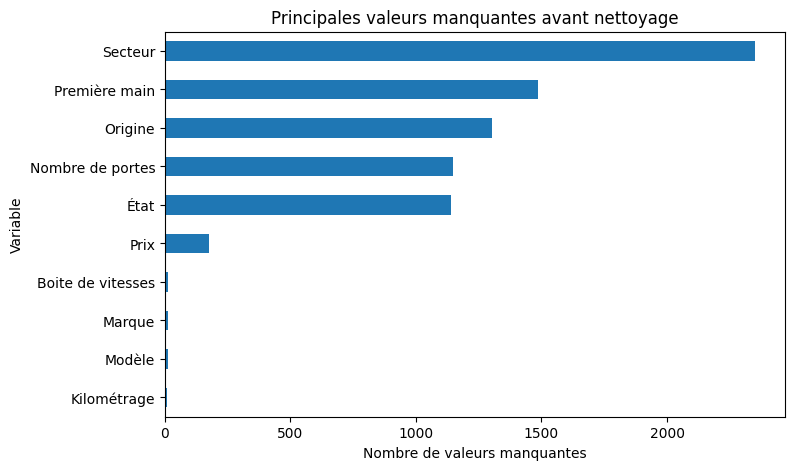

In [5]:
valeurs_manquantes = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 5))
valeurs_manquantes.sort_values().plot(kind="barh")

plt.title("Principales valeurs manquantes avant nettoyage")
plt.xlabel("Nombre de valeurs manquantes")
plt.ylabel("Variable")
plt.show()

## 3. Prétraitement

In [6]:
def convertir_kilometrage(valeur):
    if pd.isna(valeur):
        return np.nan
    texte = str(valeur).replace("\xa0", " ").strip()
    nombres = re.findall(r"\d[\d ]*", texte)
    nombres = [int(x.replace(" ", "")) for x in nombres]
    if len(nombres) == 0:
        return np.nan
    if "-" in texte and len(nombres) >= 2:
        return (nombres[0] + nombres[1]) / 2
    return nombres[0]

df["Kilométrage"] = df["Kilométrage"].apply(convertir_kilometrage)

for colonne in ["Année-Modèle", "Puissance fiscale", "Nombre de portes", "Prix"]:
    df[colonne] = pd.to_numeric(df[colonne], errors="coerce")

print("Doublons :", df.duplicated(subset=["Lien"]).sum())

Doublons : 22


In [7]:
nombre_avant = len(df)

df = df.drop_duplicates(subset=["Lien"])
df = df.dropna(subset=["Prix"])

df = df[df["Prix"].between(20000, 3000000)]
df = df[df["Kilométrage"].isna() | df["Kilométrage"].between(0, 500000)]
df = df[df["Année-Modèle"].isna() | df["Année-Modèle"].between(1980, 2026)]

equipements = [
    "Jantes aluminium", "Airbags", "Climatisation",
    "Système de navigation/GPS", "Toit ouvrant", "Sièges cuir",
    "Radar de recul", "Caméra de recul", "Vitres électriques",
    "ABS", "ESP", "Régulateur de vitesse", "Limiteur de vitesse",
    "CD/MP3/Bluetooth", "Ordinateur de bord",
    "Verrouillage centralisé à distance"
]

df["Nombre équipements"] = (
    df[equipements]
    .fillna(False)
    .astype(int)
    .sum(axis=1)
)

print("Avant nettoyage :", nombre_avant)
print("Après nettoyage :", len(df))

Avant nettoyage : 5242
Après nettoyage : 5032


In [8]:
df.to_csv("avito_car_dataset_cleaned.csv", index=False)
print("Dataset nettoyé sauvegardé.")

Dataset nettoyé sauvegardé.


## 4. Analyse exploratoire

In [9]:
df[[
    "Prix", "Année-Modèle", "Kilométrage",
    "Puissance fiscale", "Nombre de portes",
    "Nombre équipements"
]].describe().round(2)

,Prix,Année-Modèle,Kilométrage,Puissance fiscale,Nombre de portes,Nombre équipements
count,5032.00,5023.00,5023.00,5031.00,4038.00,5032.00
mean,163231.02,2013.43,129548.87,7.37,4.90,3.87
std,171807.46,6.10,86384.94,2.06,0.43,4.13
min,21000.00,1980.00,0.00,4.00,3.00,0.00
25%,82000.00,2009.00,62499.50,6.00,5.00,0.00
50%,115000.00,2014.00,124999.50,7.00,5.00,4.00
75%,173000.00,2018.00,184999.50,8.00,5.00,5.00
max,2750000.00,2026.00,474999.50,41.00,5.00,16.00


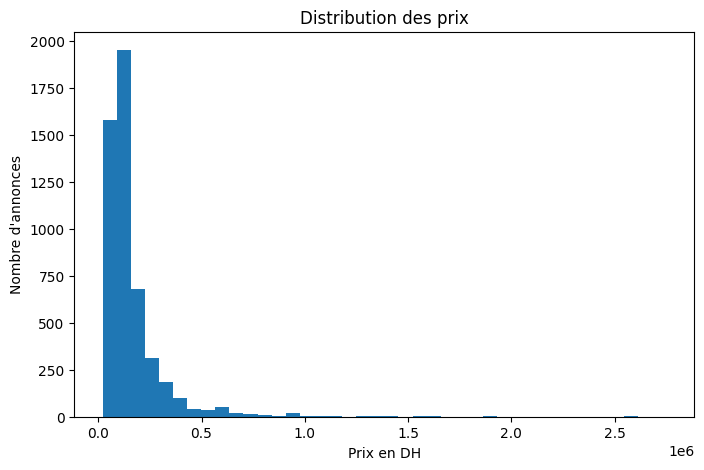

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(df["Prix"], bins=40)
plt.xlabel("Prix en DH")
plt.ylabel("Nombre d'annonces")
plt.title("Distribution des prix")
plt.show()

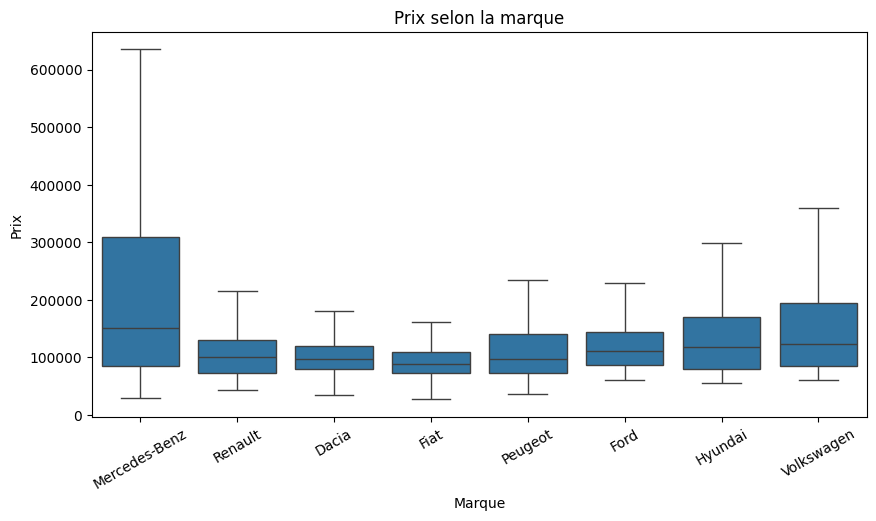

In [11]:
top_marques = df["Marque"].value_counts().head(8).index
df_top = df[df["Marque"].isin(top_marques)]

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_top, x="Marque", y="Prix", showfliers=False)
plt.xticks(rotation=30)
plt.title("Prix selon la marque")
plt.show()

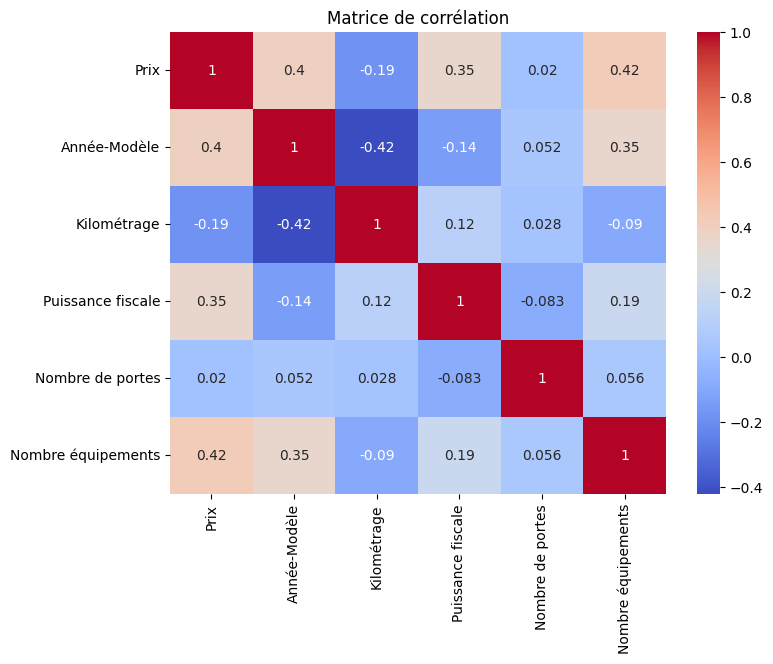

In [12]:
colonnes_corr = [
    "Prix", "Année-Modèle", "Kilométrage",
    "Puissance fiscale", "Nombre de portes",
    "Nombre équipements"
]

plt.figure(figsize=(8, 6))
sns.heatmap(df[colonnes_corr].corr(), annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

Les prix augmentent généralement avec l'année et la puissance fiscale.  
Ils diminuent souvent lorsque le kilométrage augmente.

## 5. Préparation des données

In [13]:
variables_numeriques = [
    "Année-Modèle", "Kilométrage",
    "Puissance fiscale", "Nombre de portes",
    "Nombre équipements"
]

variables_categorielles = [
    "Ville", "Marque", "Modèle",
    "Type de carburant", "Boite de vitesses"
]

X = df[variables_numeriques + variables_categorielles]
y = df["Prix"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

traitement_numerique = Pipeline([
    ("imputation", SimpleImputer(strategy="median")),
    ("standardisation", StandardScaler())
])
traitement_categoriel = Pipeline([
    ("imputation", SimpleImputer(strategy="most_frequent")),
    ("encodage", OneHotEncoder(
        handle_unknown="ignore",
        min_frequency=5
    ))
])

preparation = ColumnTransformer([
    ("num", traitement_numerique, variables_numeriques),
    ("cat", traitement_categoriel, variables_categorielles)
])

print("Train :", X_train.shape)
print("Test :", X_test.shape)

Train : (4025, 10)
Test : (1007, 10)


## 6. Modèles de régression

In [14]:
modeles = {
    "Régression linéaire": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=50,
        max_depth=12,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        n_estimators=60,
        max_depth=4,
        learning_rate=0.07,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=2
    )
}

pipelines = {}
resultats = []
predictions = {}

for nom, modele in modeles.items():
    pipeline = Pipeline([
        ("preparation", preparation),
        ("modele", modele)
    ])
    modele_final = TransformedTargetRegressor(
        regressor=pipeline,
        func=np.log1p,
        inverse_func=np.expm1
    )

    modele_final.fit(X_train, y_train)
    y_pred = modele_final.predict(X_test)

    pipelines[nom] = modele_final
    predictions[nom] = y_pred

    resultats.append({
        "Modèle": nom,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R²": r2_score(y_test, y_pred)
    })

resultats_df = pd.DataFrame(resultats).sort_values("RMSE")
resultats_df.round(2)

,Modèle,MAE,RMSE,R²
2,XGBoost,38541.66,116815.75,0.54
1,Random Forest,37554.55,118172.63,0.53
0,Régression linéaire,36965.03,122117.96,0.50


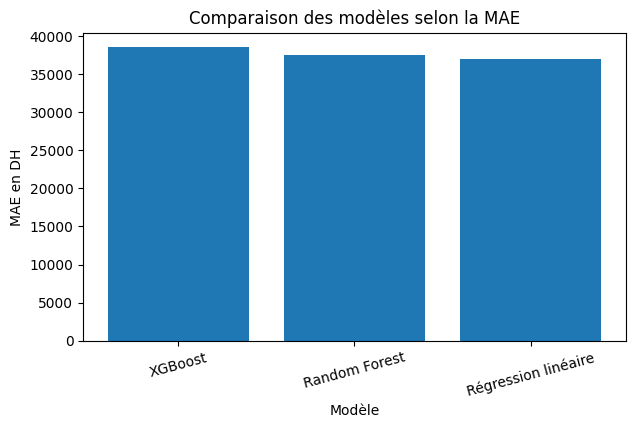

In [15]:
# Graphique MAE

plt.figure(figsize=(7, 4))
plt.bar(resultats_df["Modèle"], resultats_df["MAE"])

plt.title("Comparaison des modèles selon la MAE")
plt.xlabel("Modèle")
plt.ylabel("MAE en DH")
plt.xticks(rotation=15)

plt.show()

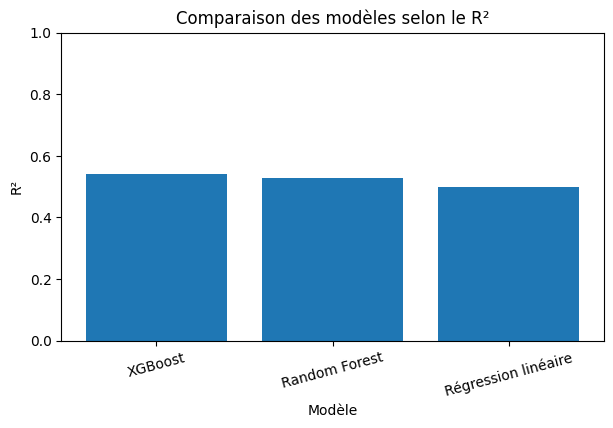

In [16]:
# Graphique R²

plt.figure(figsize=(7, 4))
plt.bar(resultats_df["Modèle"], resultats_df["R²"])

plt.title("Comparaison des modèles selon le R²")
plt.xlabel("Modèle")
plt.ylabel("R²")
plt.ylim(0, 1)
plt.xticks(rotation=15)

plt.show()

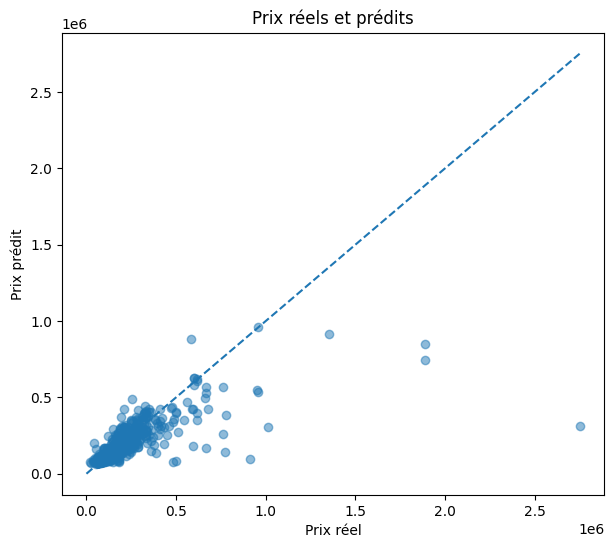

Meilleur modèle : XGBoost


In [17]:
meilleur_modele_nom = resultats_df.iloc[0]["Modèle"]
y_pred_meilleur = predictions[meilleur_modele_nom]

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_meilleur, alpha=0.5)

limite = max(y_test.max(), y_pred_meilleur.max())
plt.plot([0, limite], [0, limite], linestyle="--")

plt.xlabel("Prix réel")
plt.ylabel("Prix prédit")
plt.title("Prix réels et prédits")
plt.show()

print("Meilleur modèle :", meilleur_modele_nom)

## 7. Validation croisée à 5 folds

In [18]:
# Échantillon pris uniquement dans le jeu d'entraînement
# Le jeu de test reste totalement séparé jusqu'à l'évaluation finale
X_cv = X_train.sample(n=min(2500, len(X_train)), random_state=42)
y_cv = y_train.loc[X_cv.index]

resultats_cv = []

for nom, modele in pipelines.items():
    scores = -cross_val_score(
        modele,
        X_cv,
        y_cv,
        cv=5,
        scoring="neg_mean_absolute_error",
        n_jobs=1
    )

    resultats_cv.append({
        "Modèle": nom,
        "MAE moyenne": scores.mean(),
        "Écart-type": scores.std()
    })

pd.DataFrame(resultats_cv).sort_values("MAE moyenne").round(2)

,Modèle,MAE moyenne,Écart-type
0,Régression linéaire,39143.78,7195.47
2,XGBoost,40540.11,8848.63
1,Random Forest,41465.37,8249.10


## 8. Optimisation avec GridSearchCV

In [19]:
pipeline_rf = Pipeline([
    ("preparation", preparation),
    ("modele", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

modele_rf = TransformedTargetRegressor(
    regressor=pipeline_rf,
    func=np.log1p,
    inverse_func=np.expm1
)

grille = {
    "regressor__modele__n_estimators": [40, 60],
    "regressor__modele__max_depth": [10, 15]
}

grid_search = GridSearchCV(
    modele_rf,
    grille,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=1
)

grid_search.fit(X_cv, y_cv)

# Réentraînement du meilleur modèle sur tout le jeu d'entraînement

modele_final = grid_search.best_estimator_
modele_final.fit(X_train, y_train)

prediction_finale = modele_final.predict(X_test)

print("Meilleurs paramètres :", grid_search.best_params_)
print("MAE :", mean_absolute_error(y_test, prediction_finale))
print("RMSE :", np.sqrt(mean_squared_error(y_test, prediction_finale)))
print("R² :", r2_score(y_test, prediction_finale))

Meilleurs paramètres : {'regressor__modele__max_depth': 15, 'regressor__modele__n_estimators': 60}
MAE : 35627.68770950772
RMSE : 116404.72019075225
R² : 0.54323919672688


## 9. Variables importantes

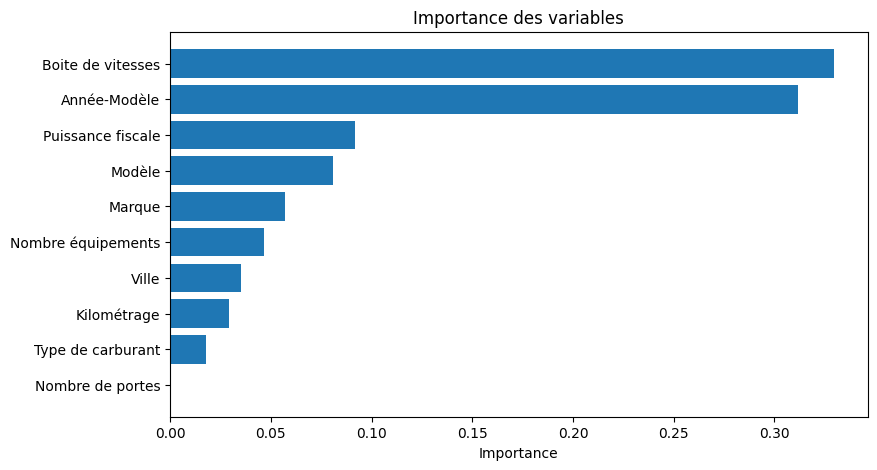

,Importance
Groupe,
Boite de vitesses,0.329754
Année-Modèle,0.311517
Puissance fiscale,0.091580
Modèle,0.080758
Marque,0.057081
Nombre équipements,0.046662
Ville,0.035056
Kilométrage,0.029135
Type de carburant,0.017809


In [20]:
meilleur_rf = grid_search.best_estimator_.regressor_

noms_variables = (
    meilleur_rf
    .named_steps["preparation"]
    .get_feature_names_out()
)

importances = (
    meilleur_rf
    .named_steps["modele"]
    .feature_importances_
)

importance_complete = pd.DataFrame({
    "Variable": noms_variables,
    "Importance": importances
})

def groupe_variable(nom):
    if "Marque_" in nom:
        return "Marque"
    if "Modèle_" in nom:
        return "Modèle"
    if "Boite de vitesses_" in nom:
        return "Boite de vitesses"
    if "Ville_" in nom:
        return "Ville"
    if "Type de carburant_" in nom:
        return "Type de carburant"
    if "Année-Modèle" in nom:
        return "Année-Modèle"
    if "Kilométrage" in nom:
        return "Kilométrage"
    if "Puissance fiscale" in nom:
        return "Puissance fiscale"
    if "Nombre équipements" in nom:
        return "Nombre équipements"
    if "Nombre de portes" in nom:
        return "Nombre de portes"
    return nom

importance_complete["Groupe"] = (
    importance_complete["Variable"].apply(groupe_variable)
)

importance_groupes = (
    importance_complete
    .groupby("Groupe")["Importance"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
plt.barh(
    importance_groupes.index[::-1],
    importance_groupes.values[::-1]
)
plt.xlabel("Importance")
plt.title("Importance des variables")
plt.show()

importance_groupes

La marque est importante pour la prédiction du prix.  
Son importance est regroupée ici pour éviter de la diviser entre Mercedes, BMW, Dacia, Renault, etc.

## 10. Clustering K-Means

In [21]:
variables_cluster = [
    "Prix", "Année-Modèle", "Kilométrage",
    "Puissance fiscale", "Nombre équipements"
]

donnees_cluster = df[variables_cluster].copy()
donnees_cluster = donnees_cluster.fillna(donnees_cluster.median())

scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(donnees_cluster)

scores = {}

for k in [2, 3, 4]:
    modele_kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = modele_kmeans.fit_predict(X_cluster)

    scores[k] = silhouette_score(
        X_cluster,
        labels,
        sample_size=1000,
        random_state=42
    )

scores
for k, score in scores.items():
    print(f"k = {k} : Silhouette Score = {score:.4f}")

k = 2 : Silhouette Score = 0.4494
k = 3 : Silhouette Score = 0.3064
k = 4 : Silhouette Score = 0.3148


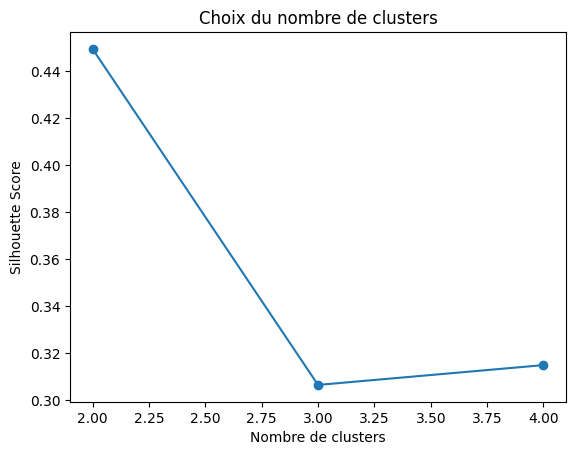

Nombre de clusters retenu : 2


,Prix,Année-Modèle,Kilométrage,Puissance fiscale,Nombre équipements
Cluster,,,,,
0,444581.65,2020.42,89574.89,8.85,12.40
1,125573.91,2012.49,134910.02,7.18,2.72


In [22]:
plt.plot(list(scores.keys()), list(scores.values()), marker="o")
plt.xlabel("Nombre de clusters")
plt.ylabel("Silhouette Score")
plt.title("Choix du nombre de clusters")
plt.show()

meilleur_k = max(scores, key=scores.get)

kmeans = KMeans(
    n_clusters=meilleur_k,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_cluster)

profil_clusters = (
    df.groupby("Cluster")[variables_cluster]
    .mean()
    .round(2)
)

print("Nombre de clusters retenu :", meilleur_k)
profil_clusters

In [23]:
effectifs_clusters = df["Cluster"].value_counts().sort_index()

print("Effectif par cluster :")
print(effectifs_clusters)

Effectif par cluster :
Cluster
0     594
1    4438
Name: count, dtype: int64


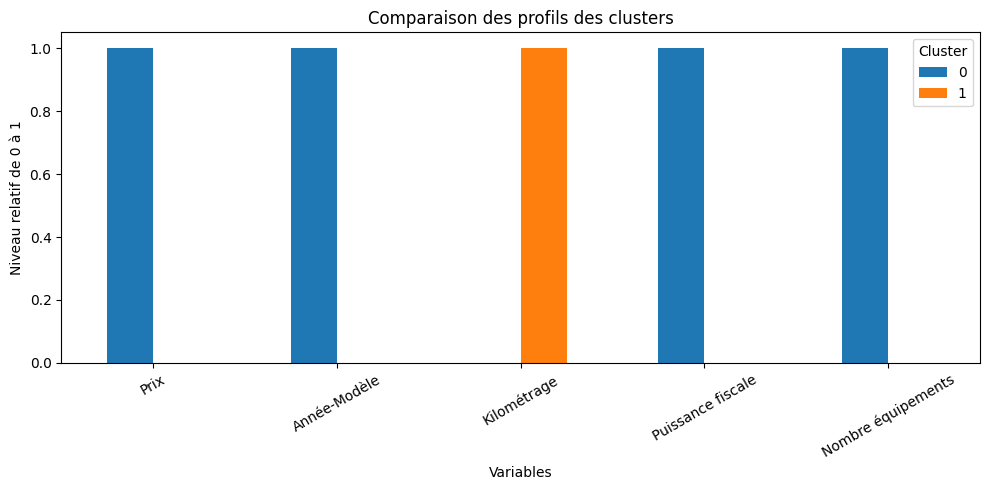

In [24]:
from sklearn.preprocessing import MinMaxScaler

scaler_profil = MinMaxScaler()

profil_normalise = pd.DataFrame(
    scaler_profil.fit_transform(profil_clusters),
    columns=profil_clusters.columns,
    index=profil_clusters.index
)

profil_normalise.T.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Comparaison des profils des clusters")
plt.xlabel("Variables")
plt.ylabel("Niveau relatif de 0 à 1")
plt.xticks(rotation=30)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

In [25]:
cluster_plus_cher = profil_clusters["Prix"].idxmax()
cluster_moins_cher = profil_clusters["Prix"].idxmin()

print(
    f"Cluster {cluster_plus_cher} : véhicules plus chers, "
    "plus récents, mieux équipés et moins kilométrés."
)

print(
    f"Cluster {cluster_moins_cher} : véhicules moins chers, "
    "plus anciens, moins équipés et plus kilométrés."
)

Cluster 0 : véhicules plus chers, plus récents, mieux équipés et moins kilométrés.
Cluster 1 : véhicules moins chers, plus anciens, moins équipés et plus kilométrés.


## 11. Inférence

In [26]:
nouvelle_voiture = pd.DataFrame([{
    "Année-Modèle": 2021,
    "Kilométrage": 65000,
    "Puissance fiscale": 7,
    "Nombre de portes": 5,
    "Nombre équipements": 10,
    "Ville": "Casablanca",
    "Marque": "Dacia",
    "Modèle": "Duster",
    "Type de carburant": "Diesel",
    "Boite de vitesses": "Manuelle"
}])

prix_estime = modele_final.predict(nouvelle_voiture)[0]

print("Prix estimé :", round(prix_estime, 2), "DH")

Prix estimé : 175787.67 DH


Le prix estimé dépend de l'année, du kilométrage, de la marque, du modèle et des autres caractéristiques fournies.

## 12. Tableau de bord analytique

In [27]:
indicateurs = pd.DataFrame({
    "Indicateur": [
        "Nombre d'annonces",
        "Prix médian",
        "Kilométrage médian",
        "Marque la plus présente"
    ],
    "Valeur": [
        len(df),
        f"{df['Prix'].median():,.0f} DH",
        f"{df['Kilométrage'].median():,.0f} km",
        df["Marque"].mode()[0]
    ]
})

indicateurs

,Indicateur,Valeur
0,Nombre d'annonces,5032
1,Prix médian,"115,000 DH"
2,Kilométrage médian,"125,000 km"
3,Marque la plus présente,Volkswagen


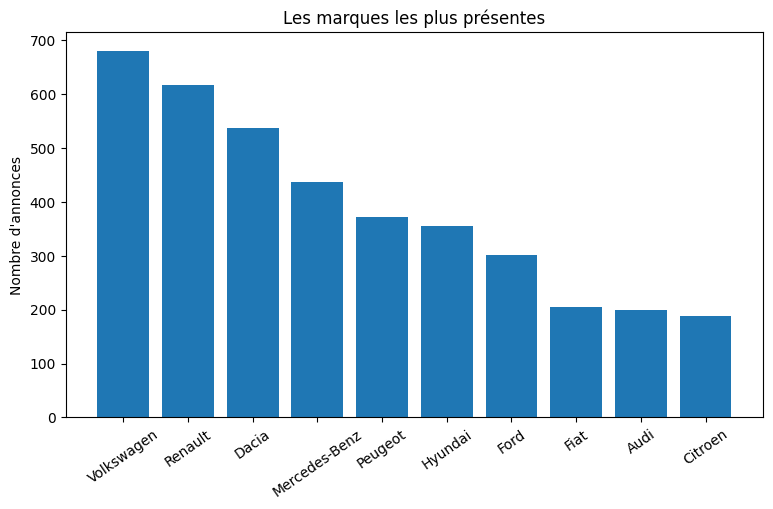

In [28]:
top_10_marques = df["Marque"].value_counts().head(10)

plt.figure(figsize=(9, 5))
plt.bar(top_10_marques.index, top_10_marques.values)
plt.xticks(rotation=35)
plt.ylabel("Nombre d'annonces")
plt.title("Les marques les plus présentes")
plt.show()

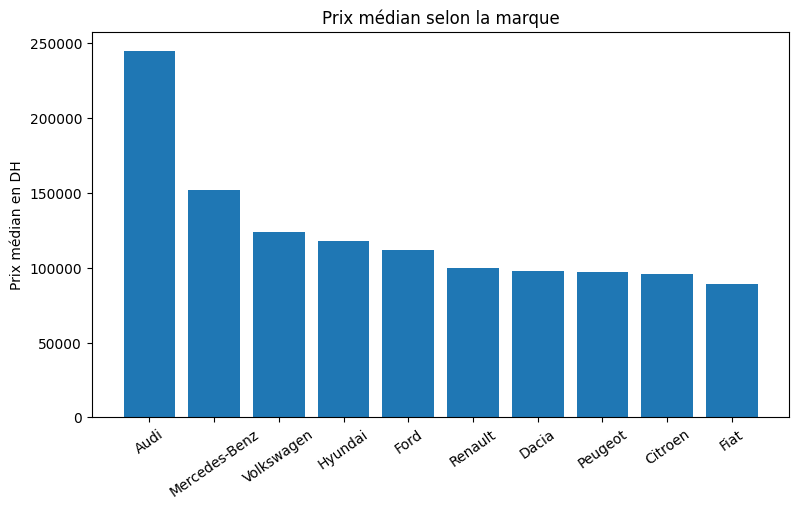

In [29]:
prix_median_marque = (
    df[df["Marque"].isin(top_10_marques.index)]
    .groupby("Marque")["Prix"]
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
plt.bar(prix_median_marque.index, prix_median_marque.values)
plt.xticks(rotation=35)
plt.ylabel("Prix médian en DH")
plt.title("Prix médian selon la marque")
plt.show()

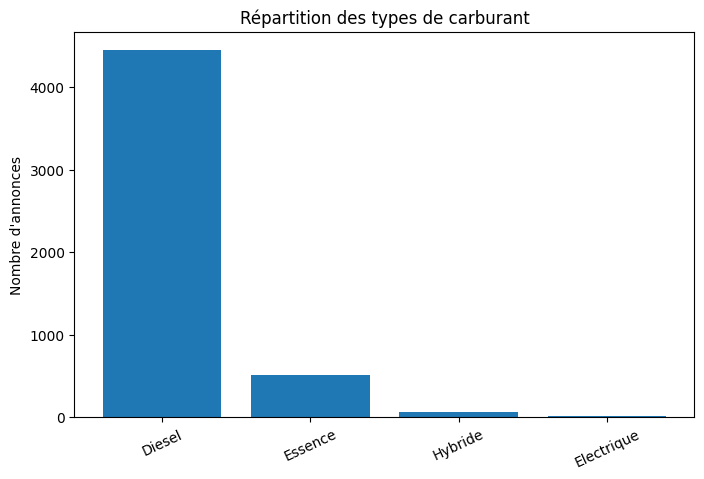

In [30]:
carburants = df["Type de carburant"].value_counts().head(6)

plt.figure(figsize=(8, 5))
plt.bar(carburants.index, carburants.values)
plt.xticks(rotation=25)
plt.ylabel("Nombre d'annonces")
plt.title("Répartition des types de carburant")
plt.show()

## 13. Conclusion

Les modèles ont été comparés avec le MAE, le RMSE et le R².  
La validation croisée à 5 folds vérifie la stabilité des résultats.  
GridSearchCV optimise le Random Forest.  
K-Means identifie des groupes de voitures similaires.  
Le tableau de bord résume les principales informations du marché.